# Neighborhood-Level Business Clustering Optimization Experiments

## Objective
Find optimal clustering parameters for ALL neighborhoods in the dataset by testing:
- Multiple feature engineering approaches (business features + review embeddings)
- Multiple dimensionality reduction techniques (PCA, UMAP, raw)
- Multiple clustering algorithms (HDBSCAN, KMeans, GMM, Agglomerative)
- Comprehensive evaluation metrics (not just silhouette!)

## Memory-Efficient Strategy
1. **Phase 1**: Pre-aggregate review embeddings per business (reuse from city experiments)
2. **Phase 2**: Process each neighborhood independently (low memory)
3. **Phase 3**: Analyze results and generate recommendations

## Key Differences from City-Level Clustering
- **Granularity**: Neighborhoods are smaller than cities, typically 10-500 businesses
- **Context**: Neighborhoods within same city may have similar characteristics
- **Goal**: Identify business segments/niches within specific neighborhoods
- **Thresholds**: Expect different optimal size thresholds than city-level

In [1]:
import numpy as np
import pandas as pd
import json
import ast
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Dimensionality reduction
from sklearn.decomposition import PCA, IncrementalPCA
from umap import UMAP

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan

# Metrics
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All imports loaded")

✓ All imports loaded


## Configuration

In [2]:
# Paths
BUSINESS_PATH = 'businesses_enriched.parquet'
REVIEW_EMBEDDINGS_PATH = 'review_embeddings.npy'
REVIEW_METADATA_PATH = 'review_metadata.parquet'
OUTPUT_DIR = Path('neighborhood_clustering_experiments')
OUTPUT_DIR.mkdir(exist_ok=True)

# Reuse cached embeddings from city experiments
BUSINESS_EMBEDDINGS_CACHE = Path('clustering_experiments') / 'business_review_embeddings.parquet'

# Results
RESULTS_DIR = OUTPUT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# Neighborhood size thresholds (initial estimates - will be refined empirically)
LARGE_NEIGHBORHOOD_THRESHOLD = 200  # Large neighborhoods
MEDIUM_NEIGHBORHOOD_THRESHOLD = 50   # Medium neighborhoods
SMALL_NEIGHBORHOOD_THRESHOLD = 20    # Small neighborhoods
TINY_NEIGHBORHOOD_THRESHOLD = 10     # Very small neighborhoods

print(f"✓ Output directory: {OUTPUT_DIR}")
print(f"✓ Results directory: {RESULTS_DIR}")
print(f"\nNeighborhood Size Thresholds (initial):")
print(f"  Large: >= {LARGE_NEIGHBORHOOD_THRESHOLD} businesses")
print(f"  Medium: {MEDIUM_NEIGHBORHOOD_THRESHOLD}-{LARGE_NEIGHBORHOOD_THRESHOLD-1} businesses")
print(f"  Small: {SMALL_NEIGHBORHOOD_THRESHOLD}-{MEDIUM_NEIGHBORHOOD_THRESHOLD-1} businesses")
print(f"  Tiny: {TINY_NEIGHBORHOOD_THRESHOLD}-{SMALL_NEIGHBORHOOD_THRESHOLD-1} businesses")
print(f"  Micro: < {TINY_NEIGHBORHOOD_THRESHOLD} businesses (rule-based only)")

✓ Output directory: neighborhood_clustering_experiments
✓ Results directory: neighborhood_clustering_experiments\results

Neighborhood Size Thresholds (initial):
  Large: >= 200 businesses
  Medium: 50-199 businesses
  Small: 20-49 businesses
  Tiny: 10-19 businesses
  Micro: < 10 businesses (rule-based only)


---
# PHASE 1: Load Cached Business Embeddings
**Reuse the pre-aggregated embeddings from city-level experiments**

In [3]:
def load_business_embeddings():
    """
    Load cached business-level review embeddings.
    Reuse from city experiments to save time.
    """
    print("="*80)
    print("LOADING BUSINESS EMBEDDINGS")
    print("="*80)
    
    if not BUSINESS_EMBEDDINGS_CACHE.exists():
        print(f"\n⚠ ERROR: Cache not found at {BUSINESS_EMBEDDINGS_CACHE}")
        print("Please run the city clustering notebook first to generate embeddings.")
        print("Or run the aggregation function from that notebook.")
        return None
    
    print(f"\n✓ Loading from cache: {BUSINESS_EMBEDDINGS_CACHE}")
    df = pd.read_parquet(BUSINESS_EMBEDDINGS_CACHE)
    
    file_size_mb = BUSINESS_EMBEDDINGS_CACHE.stat().st_size / 1024 / 1024
    print(f"✓ Loaded {len(df):,} businesses")
    print(f"✓ File size: {file_size_mb:.2f} MB")
    print(f"✓ Columns: {df.columns.tolist()}")
    
    # Check embedding dimensions
    if len(df) > 0 and 'embedding_mean' in df.columns:
        sample_emb = df['embedding_mean'].iloc[0]
        print(f"✓ Embedding dimension: {len(sample_emb)}")
    
    print("\n" + "="*80)
    print("✓ EMBEDDINGS LOADED")
    print("="*80)
    
    return df

# Load embeddings
business_embeddings = load_business_embeddings()

LOADING BUSINESS EMBEDDINGS

✓ Loading from cache: clustering_experiments\business_review_embeddings.parquet
✓ Loaded 8,078 businesses
✓ File size: 25.06 MB
✓ Columns: ['business_id', 'review_count', 'embedding_mean', 'embedding_std']
✓ Embedding dimension: 384

✓ EMBEDDINGS LOADED


---
# PHASE 2: Load and Analyze Neighborhood Data

In [4]:
# Load businesses
print("Loading businesses data...")
businesses = pd.read_parquet(BUSINESS_PATH)
print(f"✓ Loaded {len(businesses):,} businesses")

# Analyze neighborhood distribution
print(f"\nNeighborhood Coverage:")
print(f"  Businesses with neighborhood: {businesses['neighborhood'].notna().sum():,}")
print(f"  Businesses without neighborhood: {businesses['neighborhood'].isna().sum():,}")
print(f"  Total unique neighborhoods: {businesses['neighborhood'].nunique():,}")

# Filter to only businesses with neighborhoods
businesses_with_neighborhoods = businesses[businesses['neighborhood'].notna()].copy()
print(f"\n✓ Working with {len(businesses_with_neighborhoods):,} businesses across {businesses_with_neighborhoods['neighborhood'].nunique():,} neighborhoods")

Loading businesses data...
✓ Loaded 8,078 businesses

Neighborhood Coverage:
  Businesses with neighborhood: 7,924
  Businesses without neighborhood: 154
  Total unique neighborhoods: 814

✓ Working with 7,924 businesses across 814 neighborhoods


In [5]:
# Analyze neighborhood sizes
neighborhood_counts = businesses_with_neighborhoods.groupby('neighborhood').size().sort_values(ascending=False)

print(f"\nNeighborhood Size Statistics:")
print(f"  Mean: {neighborhood_counts.mean():.1f} businesses")
print(f"  Median: {neighborhood_counts.median():.1f} businesses")
print(f"  Min: {neighborhood_counts.min()} businesses")
print(f"  Max: {neighborhood_counts.max()} businesses")
print(f"  25th percentile: {neighborhood_counts.quantile(0.25):.1f}")
print(f"  75th percentile: {neighborhood_counts.quantile(0.75):.1f}")
print(f"  90th percentile: {neighborhood_counts.quantile(0.90):.1f}")

# Categorize neighborhoods by size
neighborhoods_large = neighborhood_counts[neighborhood_counts >= LARGE_NEIGHBORHOOD_THRESHOLD].index.tolist()
neighborhoods_medium = neighborhood_counts[
    (neighborhood_counts >= MEDIUM_NEIGHBORHOOD_THRESHOLD) & 
    (neighborhood_counts < LARGE_NEIGHBORHOOD_THRESHOLD)
].index.tolist()
neighborhoods_small = neighborhood_counts[
    (neighborhood_counts >= SMALL_NEIGHBORHOOD_THRESHOLD) & 
    (neighborhood_counts < MEDIUM_NEIGHBORHOOD_THRESHOLD)
].index.tolist()
neighborhoods_tiny = neighborhood_counts[
    (neighborhood_counts >= TINY_NEIGHBORHOOD_THRESHOLD) & 
    (neighborhood_counts < SMALL_NEIGHBORHOOD_THRESHOLD)
].index.tolist()
neighborhoods_micro = neighborhood_counts[neighborhood_counts < TINY_NEIGHBORHOOD_THRESHOLD].index.tolist()

print(f"\nNeighborhood Distribution by Size:")
print(f"  Large (>={LARGE_NEIGHBORHOOD_THRESHOLD}): {len(neighborhoods_large)} neighborhoods")
print(f"  Medium ({MEDIUM_NEIGHBORHOOD_THRESHOLD}-{LARGE_NEIGHBORHOOD_THRESHOLD-1}): {len(neighborhoods_medium)} neighborhoods")
print(f"  Small ({SMALL_NEIGHBORHOOD_THRESHOLD}-{MEDIUM_NEIGHBORHOOD_THRESHOLD-1}): {len(neighborhoods_small)} neighborhoods")
print(f"  Tiny ({TINY_NEIGHBORHOOD_THRESHOLD}-{SMALL_NEIGHBORHOOD_THRESHOLD-1}): {len(neighborhoods_tiny)} neighborhoods")
print(f"  Micro (<{TINY_NEIGHBORHOOD_THRESHOLD}): {len(neighborhoods_micro)} neighborhoods (will skip clustering)")


Neighborhood Size Statistics:
  Mean: 9.7 businesses
  Median: 3.0 businesses
  Min: 1 businesses
  Max: 468 businesses
  25th percentile: 1.0
  75th percentile: 8.0
  90th percentile: 17.0

Neighborhood Distribution by Size:
  Large (>=200): 5 neighborhoods
  Medium (50-199): 18 neighborhoods
  Small (20-49): 47 neighborhoods
  Tiny (10-19): 95 neighborhoods
  Micro (<10): 649 neighborhoods (will skip clustering)


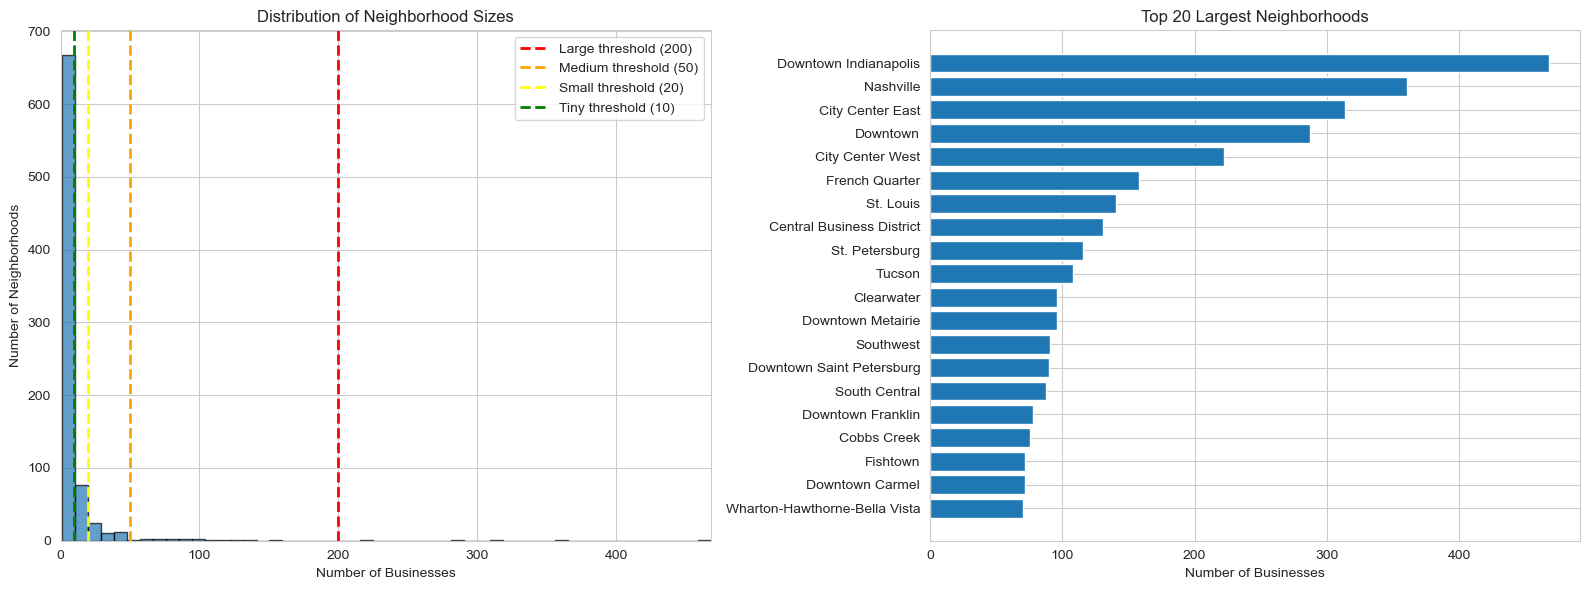


✓ Saved visualization: neighborhood_clustering_experiments\neighborhood_size_distribution.png


In [6]:
# Visualize neighborhood distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of neighborhood sizes
ax = axes[0]
ax.hist(neighborhood_counts, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=LARGE_NEIGHBORHOOD_THRESHOLD, color='r', linestyle='--', 
           label=f'Large threshold ({LARGE_NEIGHBORHOOD_THRESHOLD})', linewidth=2)
ax.axvline(x=MEDIUM_NEIGHBORHOOD_THRESHOLD, color='orange', linestyle='--', 
           label=f'Medium threshold ({MEDIUM_NEIGHBORHOOD_THRESHOLD})', linewidth=2)
ax.axvline(x=SMALL_NEIGHBORHOOD_THRESHOLD, color='yellow', linestyle='--', 
           label=f'Small threshold ({SMALL_NEIGHBORHOOD_THRESHOLD})', linewidth=2)
ax.axvline(x=TINY_NEIGHBORHOOD_THRESHOLD, color='green', linestyle='--', 
           label=f'Tiny threshold ({TINY_NEIGHBORHOOD_THRESHOLD})', linewidth=2)
ax.set_xlabel('Number of Businesses')
ax.set_ylabel('Number of Neighborhoods')
ax.set_title('Distribution of Neighborhood Sizes')
ax.legend()
ax.set_xlim(0, min(500, neighborhood_counts.max()))

# Top 20 neighborhoods
ax = axes[1]
top_20 = neighborhood_counts.head(20)
ax.barh(range(len(top_20)), top_20.values)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index)
ax.set_xlabel('Number of Businesses')
ax.set_title('Top 20 Largest Neighborhoods')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'neighborhood_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved visualization: {OUTPUT_DIR / 'neighborhood_size_distribution.png'}")

---
# PHASE 3: Feature Engineering Functions
**Reuse same feature engineering as city-level experiments**

In [7]:
def parse_nested_attributes(attr_dict):
    """
    Parse nested JSON-like attributes into flat features.
    """
    if not attr_dict or not isinstance(attr_dict, dict):
        return {}
    
    flat_attrs = {}
    
    for key, value in attr_dict.items():
        if value is None:
            continue
            
        # Handle string representations of dicts/lists
        if isinstance(value, str):
            if value in ['True', 'true']:
                flat_attrs[key] = 1
            elif value in ['False', 'false']:
                flat_attrs[key] = 0
            elif value.startswith('{') or value.startswith('['):
                try:
                    parsed = ast.literal_eval(value)
                    if isinstance(parsed, dict):
                        for sub_key, sub_val in parsed.items():
                            if isinstance(sub_val, bool):
                                flat_attrs[f"{key}_{sub_key}"] = int(sub_val)
                            elif sub_val is True:
                                flat_attrs[f"{key}_{sub_key}"] = 1
                            elif sub_val is False:
                                flat_attrs[f"{key}_{sub_key}"] = 0
                except:
                    pass
            elif value.startswith("u'") or value.startswith("'"):
                # Categorical - store as string for later one-hot encoding
                flat_attrs[key] = value.strip("u'").strip("'")
        elif isinstance(value, (int, float)):
            flat_attrs[key] = value
    
    return flat_attrs


def extract_business_features(neighborhood_businesses):
    """
    Extract and engineer business features using high-coverage attributes.
    Based on attribute analysis: focus on >=80% coverage attributes.
    
    High-coverage attributes (>=80%):
    - BusinessParking, RestaurantsTakeOut, RestaurantsDelivery, OutdoorSeating
    - BusinessAcceptsCreditCards, RestaurantsPriceRange2, HasTV, Ambience
    - WiFi, Alcohol, RestaurantsReservations, Caters, RestaurantsGoodForGroups
    - BikeParking, NoiseLevel, GoodForKids, GoodForMeal, RestaurantsAttire
    """
    features = neighborhood_businesses.copy()

    # Numerical features from enriched data
    numerical_cols = [
        'latitude', 'longitude', 'stars', 'review_count', 'photo_count',
        'avg_sentiment_score', 'avg_sentiment_prob_diff', 'avg_review_stars',
        'sentiment_volatility', 'business_age_days', 'review_velocity',
        'competitive_position_rating', 'competitive_position_sentiment'
    ]

    numerical_features = features[[col for col in numerical_cols if col in features.columns]].fillna(0)

    # High-coverage attributes (>=80% coverage from analysis)
    high_coverage_attrs = [
        'BusinessParking', 'RestaurantsTakeOut', 'RestaurantsDelivery',
        'OutdoorSeating', 'BusinessAcceptsCreditCards', 'RestaurantsPriceRange2',
        'HasTV', 'Ambience', 'WiFi', 'Alcohol', 'RestaurantsReservations',
        'Caters', 'RestaurantsGoodForGroups', 'BikeParking', 'NoiseLevel',
        'GoodForKids', 'GoodForMeal', 'RestaurantsAttire'
    ]

    # Parse attributes
    if 'attributes' in features.columns:
        parsed_attrs = []
        for _, row in features.iterrows():
            attrs = row['attributes']
            if isinstance(attrs, str):
                try:
                    attrs = ast.literal_eval(attrs)
                except:
                    attrs = {}

            # Extract only high-coverage attributes
            if isinstance(attrs, dict):
                filtered_attrs = {k: v for k, v in attrs.items() if k in high_coverage_attrs}
            else:
                filtered_attrs = {}

            parsed_attrs.append(parse_nested_attributes(filtered_attrs))

        attr_df = pd.DataFrame(parsed_attrs, index=features.index)

        # Convert to numeric where possible
        attr_numeric = attr_df.select_dtypes(include=[np.number]).fillna(0)

        # Handle categorical attributes (one-hot encode if few unique values)
        attr_categorical = attr_df.select_dtypes(include=['object'])
        if len(attr_categorical.columns) > 0:
            # One-hot encode categorical with few unique values (<10)
            for col in attr_categorical.columns:
                if attr_categorical[col].nunique() < 10 and attr_categorical[col].nunique() > 1:
                    dummies = pd.get_dummies(attr_categorical[col], prefix=col, drop_first=True)
                    attr_numeric = pd.concat([attr_numeric, dummies], axis=1)

        # Combine all features
        all_features = pd.concat([numerical_features, attr_numeric], axis=1)
    else:
        all_features = numerical_features

    return all_features


def prepare_feature_variants(neighborhood_businesses, neighborhood_embeddings):
    """
    Prepare multiple feature engineering variants to test.
    Returns dict of {variant_name: feature_matrix}
    """
    variants = {}
    
    # 1. Business features only
    business_features = extract_business_features(neighborhood_businesses)
    scaler = StandardScaler()
    business_scaled = scaler.fit_transform(business_features)
    variants['business_only'] = business_scaled
    
    # Merge embeddings
    merged = neighborhood_businesses[['business_id']].merge(
        neighborhood_embeddings, on='business_id', how='left'
    )
    
    # 2. Review embeddings only - mean
    if 'embedding_mean' in merged.columns:
        emb_mean = np.vstack(merged['embedding_mean'].fillna(
            lambda: np.zeros(384)
        ).values)
        variants['embedding_mean_only'] = emb_mean
        
        # 3. Review embeddings - mean + std
        if 'embedding_std' in merged.columns:
            emb_std = np.vstack(merged['embedding_std'].fillna(
                lambda: np.zeros(384)
            ).values)
            emb_combined = np.hstack([emb_mean, emb_std])
            variants['embedding_mean_std'] = emb_combined
        
        # 4. Business + embedding mean
        variants['business_plus_embedding_mean'] = np.hstack([
            business_scaled, emb_mean
        ])
        
        # 5. Business + embedding mean+std
        if 'embedding_std' in merged.columns:
            variants['business_plus_embedding_mean_std'] = np.hstack([
                business_scaled, emb_combined
            ])
    
    return variants

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


---
# PHASE 4: Dimensionality Reduction Functions

In [8]:
def apply_dimensionality_reduction(features, method_configs):
    """
    Apply various dimensionality reduction techniques.
    
    Args:
        features: numpy array of features
        method_configs: list of dicts with {'method': str, 'params': dict}
    
    Returns:
        dict of {config_name: reduced_features}
    """
    results = {}
    results['raw'] = features  # Always include raw features
    
    for config in method_configs:
        method = config['method']
        params = config.get('params', {})
        
        try:
            if method == 'pca':
                n_components = params.get('n_components', 50)
                n_components = min(n_components, features.shape[0]-1, features.shape[1])
                
                reducer = PCA(n_components=n_components, random_state=42)
                reduced = reducer.fit_transform(features)
                
                config_name = f"pca_{n_components}"
                results[config_name] = reduced
                
            elif method == 'umap':
                n_neighbors = params.get('n_neighbors', 15)
                n_components = params.get('n_components', 50)
                min_dist = params.get('min_dist', 0.1)
                metric = params.get('metric', 'euclidean')
                
                # Adjust for small datasets
                n_neighbors = min(n_neighbors, features.shape[0] - 1)
                n_components = min(n_components, features.shape[0] - 1, features.shape[1])
                
                reducer = UMAP(
                    n_neighbors=n_neighbors,
                    n_components=n_components,
                    min_dist=min_dist,
                    metric=metric,
                    random_state=42
                )
                reduced = reducer.fit_transform(features)
                
                config_name = f"umap_n{n_neighbors}_c{n_components}_d{min_dist}_{metric}"
                results[config_name] = reduced
                
        except Exception as e:
            print(f"   ⚠ Skipped {method} with {params}: {e}")
            continue
    
    return results

print("✓ Dimensionality reduction functions defined")

✓ Dimensionality reduction functions defined


---
# PHASE 5: Clustering Functions

In [9]:
def cluster_hdbscan(features, params):
    """
    Cluster using HDBSCAN.
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=params.get('min_cluster_size', 10),
        min_samples=params.get('min_samples', 5),
        cluster_selection_epsilon=params.get('cluster_selection_epsilon', 0.0),
        cluster_selection_method=params.get('cluster_selection_method', 'eom'),
        metric=params.get('metric', 'euclidean')
    )
    
    labels = clusterer.fit_predict(features)
    
    return {
        'labels': labels,
        'probabilities': clusterer.probabilities_,
        'outlier_scores': clusterer.outlier_scores_,
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
        'noise_ratio': (labels == -1).sum() / len(labels),
        'clusterer': clusterer
    }


def cluster_kmeans(features, params):
    """
    Cluster using KMeans.
    """
    n_clusters = params.get('n_clusters', 5)
    n_clusters = min(n_clusters, features.shape[0] - 1)  # Ensure valid k
    
    clusterer = KMeans(
        n_clusters=n_clusters,
        n_init=50,
        random_state=42
    )
    
    labels = clusterer.fit_predict(features)
    
    return {
        'labels': labels,
        'n_clusters': n_clusters,
        'inertia': clusterer.inertia_,
        'clusterer': clusterer
    }


def cluster_gmm(features, params):
    """
    Cluster using Gaussian Mixture Model.
    """
    n_components = params.get('n_components', 5)
    n_components = min(n_components, features.shape[0] - 1)
    
    clusterer = GaussianMixture(
        n_components=n_components,
        covariance_type=params.get('covariance_type', 'full'),
        random_state=42
    )
    
    labels = clusterer.fit_predict(features)
    
    return {
        'labels': labels,
        'n_clusters': n_components,
        'bic': clusterer.bic(features),
        'aic': clusterer.aic(features),
        'clusterer': clusterer
    }


def cluster_agglomerative(features, params):
    """
    Cluster using Agglomerative Clustering.
    """
    n_clusters = params.get('n_clusters', 5)
    n_clusters = min(n_clusters, features.shape[0] - 1)
    
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=params.get('linkage', 'ward')
    )
    
    labels = clusterer.fit_predict(features)
    
    return {
        'labels': labels,
        'n_clusters': n_clusters,
        'clusterer': clusterer
    }

print("✓ Clustering functions defined")

✓ Clustering functions defined


---
# PHASE 6: Evaluation Metrics

In [10]:
def compute_cluster_metrics(features, labels, neighborhood_size):
    """
    Compute comprehensive cluster quality metrics.
    """
    metrics = {}
    
    # Filter out noise points for HDBSCAN
    valid_mask = labels >= 0
    valid_features = features[valid_mask]
    valid_labels = labels[valid_mask]
    
    n_clusters = len(set(valid_labels))
    noise_ratio = (~valid_mask).sum() / len(labels)
    
    metrics['n_clusters'] = n_clusters
    metrics['noise_ratio'] = noise_ratio
    metrics['n_valid_samples'] = len(valid_labels)
    
    # Need at least 2 clusters and reasonable samples
    if n_clusters < 2 or len(valid_labels) < 10:
        metrics['silhouette'] = -1
        metrics['davies_bouldin'] = np.inf
        metrics['calinski_harabasz'] = 0
        metrics['validity'] = False
        return metrics
    
    metrics['validity'] = True
    
    # Silhouette Score
    try:
        metrics['silhouette'] = silhouette_score(valid_features, valid_labels)
    except:
        metrics['silhouette'] = -1
    
    # Davies-Bouldin Index (lower is better)
    try:
        metrics['davies_bouldin'] = davies_bouldin_score(valid_features, valid_labels)
    except:
        metrics['davies_bouldin'] = np.inf
    
    # Calinski-Harabasz Score (higher is better)
    try:
        metrics['calinski_harabasz'] = calinski_harabasz_score(valid_features, valid_labels)
    except:
        metrics['calinski_harabasz'] = 0
    
    # Cluster size statistics
    cluster_sizes = pd.Series(valid_labels).value_counts().sort_index()
    metrics['cluster_sizes'] = cluster_sizes.tolist()
    metrics['min_cluster_size'] = cluster_sizes.min()
    metrics['max_cluster_size'] = cluster_sizes.max()
    metrics['mean_cluster_size'] = cluster_sizes.mean()
    metrics['cluster_size_std'] = cluster_sizes.std()
    
    # Balance score (penalize very imbalanced clusters)
    size_cv = metrics['cluster_size_std'] / metrics['mean_cluster_size'] if metrics['mean_cluster_size'] > 0 else np.inf
    metrics['cluster_balance'] = 1 / (1 + size_cv)  # 0-1, higher is better
    
    # Separation metric (minimum distance between centroids)
    try:
        centroids = []
        for label in set(valid_labels):
            cluster_points = valid_features[valid_labels == label]
            centroids.append(cluster_points.mean(axis=0))
        
        if len(centroids) >= 2:
            centroid_distances = cdist(centroids, centroids)
            np.fill_diagonal(centroid_distances, np.inf)
            metrics['min_centroid_distance'] = centroid_distances.min()
            metrics['mean_centroid_distance'] = centroid_distances[centroid_distances != np.inf].mean()
        else:
            metrics['min_centroid_distance'] = 0
            metrics['mean_centroid_distance'] = 0
    except:
        metrics['min_centroid_distance'] = 0
        metrics['mean_centroid_distance'] = 0
    
    # Composite score (weighted combination)
    # Normalize metrics to 0-1 range
    silhouette_norm = (metrics['silhouette'] + 1) / 2  # -1 to 1 -> 0 to 1
    db_norm = max(0, 1 - metrics['davies_bouldin'] / 10)  # Lower is better
    ch_norm = min(1, metrics['calinski_harabasz'] / 1000)  # Higher is better
    
    # Penalize extreme noise and imbalance
    noise_penalty = 1 - metrics['noise_ratio']
    balance_score = metrics['cluster_balance']
    
    # Weighted composite
    metrics['composite_score'] = (
        0.25 * silhouette_norm +
        0.20 * db_norm +
        0.20 * ch_norm +
        0.20 * noise_penalty +
        0.15 * balance_score
    )
    
    return metrics

print("✓ Evaluation metrics functions defined")

✓ Evaluation metrics functions defined


---
# PHASE 7: Experiment Configuration

In [11]:
def get_clustering_configs(neighborhood_size, n_samples):
    """
    Get clustering configurations based on neighborhood size.
    Adjusted for neighborhood-level clustering (smaller than cities).
    """
    configs = []
    
    if neighborhood_size == 'large':  # >= 200
        # HDBSCAN grid
        for min_cluster_size in [5, 10, 15, 20, 30]:
            for min_samples in [3, 5, 10]:
                for epsilon in [0.0, 0.1, 0.3]:
                    configs.append({
                        'method': 'hdbscan',
                        'params': {
                            'min_cluster_size': min_cluster_size,
                            'min_samples': min_samples,
                            'cluster_selection_epsilon': epsilon,
                            'metric': 'euclidean'
                        }
                    })
        
        # KMeans for comparison
        for k in [3, 4, 5, 6, 8, 10, 12, 15]:
            configs.append({
                'method': 'kmeans',
                'params': {'n_clusters': k}
            })
        
        # GMM
        for k in [3, 5, 8, 10, 12]:
            configs.append({
                'method': 'gmm',
                'params': {'n_components': k, 'covariance_type': 'full'}
            })
    
    elif neighborhood_size == 'medium':  # 50-199
        # HDBSCAN
        for min_cluster_size in [5, 10, 15]:
            for min_samples in [3, 5]:
                configs.append({
                    'method': 'hdbscan',
                    'params': {
                        'min_cluster_size': min_cluster_size,
                        'min_samples': min_samples,
                        'cluster_selection_epsilon': 0.0
                    }
                })
        
        # KMeans
        for k in [2, 3, 4, 5, 6, 8, 10]:
            configs.append({
                'method': 'kmeans',
                'params': {'n_clusters': k}
            })
        
        # GMM
        for k in [3, 4, 5, 6, 8]:
            configs.append({
                'method': 'gmm',
                'params': {'n_components': k}
            })
    
    elif neighborhood_size == 'small':  # 20-49
        # Primarily KMeans
        for k in [2, 3, 4, 5, 6]:
            configs.append({
                'method': 'kmeans',
                'params': {'n_clusters': k}
            })
        
        # Try HDBSCAN with small params
        for min_cluster_size in [5, 8]:
            configs.append({
                'method': 'hdbscan',
                'params': {
                    'min_cluster_size': min_cluster_size,
                    'min_samples': 3
                }
            })
        
        # Agglomerative
        for k in [2, 3, 4, 5]:
            configs.append({
                'method': 'agglomerative',
                'params': {'n_clusters': k, 'linkage': 'ward'}
            })
        
        # GMM
        for k in [2, 3, 4, 5]:
            configs.append({
                'method': 'gmm',
                'params': {'n_components': k}
            })
    
    elif neighborhood_size == 'tiny':  # 10-19
        # Simple KMeans
        for k in [2, 3, 4]:
            configs.append({
                'method': 'kmeans',
                'params': {'n_clusters': min(k, n_samples-1)}
            })
        
        # Agglomerative
        for k in [2, 3]:
            configs.append({
                'method': 'agglomerative',
                'params': {'n_clusters': min(k, n_samples-1)}
            })
    
    return configs


def get_dimred_configs(neighborhood_size, n_features):
    """
    Get dimensionality reduction configurations.
    Adjusted for neighborhood-level (typically smaller sample sizes).
    """
    configs = []
    
    if neighborhood_size in ['large', 'medium']:
        # PCA variants
        for n_comp in [20, 50, 100, 150]:
            if n_comp < n_features:
                configs.append({
                    'method': 'pca',
                    'params': {'n_components': n_comp}
                })
        
        # UMAP variants
        for n_neighbors in [5, 10, 15]:
            for n_comp in [10, 20, 50]:
                for min_dist in [0.0, 0.1, 0.3]:
                    if n_comp < n_features:
                        configs.append({
                            'method': 'umap',
                            'params': {
                                'n_neighbors': n_neighbors,
                                'n_components': n_comp,
                                'min_dist': min_dist,
                                'metric': 'euclidean'
                            }
                        })
    
    elif neighborhood_size in ['small', 'tiny']:
        # Simpler configs for small neighborhoods
        for n_comp in [10, 20]:
            if n_comp < n_features:
                configs.append({
                    'method': 'pca',
                    'params': {'n_components': n_comp}
                })
        
        configs.append({
            'method': 'umap',
            'params': {
                'n_neighbors': 5,
                'n_components': 10,
                'min_dist': 0.1
            }
        })
    
    return configs

print("✓ Experiment configuration functions defined")

✓ Experiment configuration functions defined


---
# PHASE 8: Neighborhood Experiment Runner

In [ ]:
def run_neighborhood_experiments(neighborhood_name, neighborhood_businesses, neighborhood_embeddings, neighborhood_size, city_name=None):
    """
    Run all experiments for a single neighborhood.
    """
    display_name = f"{neighborhood_name} ({city_name})" if city_name else neighborhood_name
    
    print(f"\n{'='*80}")
    print(f"NEIGHBORHOOD: {display_name} ({neighborhood_size.upper()})")
    print(f"Businesses: {len(neighborhood_businesses)}")
    print(f"{'='*80}\n")
    
    results = []
    
    # 1. Prepare feature variants
    print("1. Preparing feature variants...")
    feature_variants = prepare_feature_variants(neighborhood_businesses, neighborhood_embeddings)
    print(f"   ✓ Created {len(feature_variants)} feature variants")
    
    # 2. For each feature variant
    for feat_name, features in feature_variants.items():
        print(f"\n2. Processing: {feat_name} (shape: {features.shape})")
        
        # Get dimensionality reduction configs
        dimred_configs = get_dimred_configs(neighborhood_size, features.shape[1])
        
        # Apply dimensionality reduction
        print(f"   → Testing {len(dimred_configs)+1} dim reduction configs...")
        reduced_variants = apply_dimensionality_reduction(features, dimred_configs)
        
        # 3. For each reduced variant
        for dimred_name, reduced_features in reduced_variants.items():
            print(f"     → {dimred_name} (shape: {reduced_features.shape})")
            
            # Get clustering configs
            clustering_configs = get_clustering_configs(neighborhood_size, len(reduced_features))
            
            # 4. For each clustering config
            for cluster_config in tqdm(clustering_configs, desc=f"       Clustering", leave=False):
                method = cluster_config['method']
                params = cluster_config['params']
                
                try:
                    # Cluster
                    if method == 'hdbscan':
                        cluster_result = cluster_hdbscan(reduced_features, params)
                    elif method == 'kmeans':
                        cluster_result = cluster_kmeans(reduced_features, params)
                    elif method == 'gmm':
                        cluster_result = cluster_gmm(reduced_features, params)
                    elif method == 'agglomerative':
                        cluster_result = cluster_agglomerative(reduced_features, params)
                    else:
                        continue
                    
                    # Evaluate
                    metrics = compute_cluster_metrics(S
                        reduced_features,
                        cluster_result['labels'],
                        neighborhood_size
                    )
                    
                    # Store result
                    result = {
                        'neighborhood': neighborhood_name,
                        'city': city_name if city_name else 'Unknown',
                        'neighborhood_size': neighborhood_size,
                        'n_businesses': len(neighborhood_businesses),
                        'feature_variant': feat_name,
                        'feature_dim': features.shape[1],
                        'dimred': dimred_name,
                        'reduced_dim': reduced_features.shape[1],
                        'clustering_method': method,
                        'clustering_params': json.dumps(params),
                        **metrics
                    }
                    
                    results.append(result)
                    
                except Exception as e:
                    print(f"         ⚠ Error: {e}")
                    continue
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Save results
    safe_name = neighborhood_name.replace(' ', '_').replace('/', '_')
    output_file = RESULTS_DIR / f"{safe_name}_results.csv"
    results_df.to_csv(output_file, index=False)
    
    print(f"\n{'='*80}")
    print(f"✓ COMPLETED {display_name}")
    print(f"✓ Tested {len(results)} configurations")
    print(f"✓ Saved: {output_file}")
    print(f"{'='*80}")
    
    return results_df

print("✓ Neighborhood experiment runner defined")

✓ Neighborhood experiment runner defined


---
# PHASE 9: Run Experiments on All Neighborhoods

In [13]:
# Select neighborhoods to process
# Process all large, medium, small neighborhoods
# Sample from tiny neighborhoods
# Skip micro neighborhoods (< 10 businesses)

neighborhoods_to_process = []

# Process all large neighborhoods
neighborhoods_to_process += [
    (neighborhood, 'large') for neighborhood in neighborhoods_large
]

# Process all medium neighborhoods
neighborhoods_to_process += [
    (neighborhood, 'medium') for neighborhood in neighborhoods_medium
]

# Process all small neighborhoods
neighborhoods_to_process += [
    (neighborhood, 'small') for neighborhood in neighborhoods_small
]

# Sample tiny neighborhoods (20 representative ones)
import random
random.seed(42)
sampled_tiny = random.sample(neighborhoods_tiny, min(20, len(neighborhoods_tiny)))
neighborhoods_to_process += [
    (neighborhood, 'tiny') for neighborhood in sampled_tiny
]

print(f"\nTotal neighborhoods to process: {len(neighborhoods_to_process)}")
print(f"\nBreakdown:")
print(f"  Large: {len(neighborhoods_large)}")
print(f"  Medium: {len(neighborhoods_medium)}")
print(f"  Small: {len(neighborhoods_small)}")
print(f"  Tiny (sampled): {len(sampled_tiny)}")
print(f"\nFirst 10: {[n[0] for n in neighborhoods_to_process[:10]]}")


Total neighborhoods to process: 90

Breakdown:
  Large: 5
  Medium: 18
  Small: 47
  Tiny (sampled): 20

First 10: ['Downtown Indianapolis', 'Nashville', 'City Center East', 'Downtown', 'City Center West', 'French Quarter', 'St. Louis', 'Central Business District', 'St. Petersburg', 'Tucson']


In [14]:
# Run experiments
print("\n" + "="*80)
print("STARTING NEIGHBORHOOD CLUSTERING EXPERIMENTS")
print("="*80)

all_results = []

for neighborhood_name, neighborhood_size in tqdm(neighborhoods_to_process, desc="Neighborhoods"):
    try:
        # Filter businesses for this neighborhood
        neighborhood_businesses = businesses_with_neighborhoods[
            businesses_with_neighborhoods['neighborhood'] == neighborhood_name
        ].copy()
        
        # Get city for display
        city_name = neighborhood_businesses['city'].mode()[0] if len(neighborhood_businesses) > 0 else None
        
        # Get embeddings for these businesses
        neighborhood_embeddings_subset = business_embeddings[
            business_embeddings['business_id'].isin(neighborhood_businesses['business_id'])
        ].copy()
        
        # Run experiments
        neighborhood_results = run_neighborhood_experiments(
            neighborhood_name,
            neighborhood_businesses,
            neighborhood_embeddings_subset,
            neighborhood_size,
            city_name
        )
        
        all_results.append(neighborhood_results)
        
        # Clear memory
        del neighborhood_businesses, neighborhood_embeddings_subset, neighborhood_results
        
    except Exception as e:
        print(f"\n⚠ ERROR processing {neighborhood_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "="*80)
print("✓ ALL NEIGHBORHOOD EXPERIMENTS COMPLETE")
print("="*80)


STARTING NEIGHBORHOOD CLUSTERING EXPERIMENTS


Neighborhoods:   0%|          | 0/90 [00:00<?, ?it/s]


NEIGHBORHOOD: Downtown Indianapolis (Indianapolis) (LARGE)
Businesses: 468

1. Preparing feature variants...
   ✓ Created 5 feature variants

2. Processing: business_only (shape: (468, 43))
   → Testing 20 dim reduction configs...
     → raw (shape: (468, 43))


     → pca_20 (shape: (468, 20))


     → umap_n5_c10_d0.0_euclidean (shape: (468, 10))


...

     → pca_10 (shape: (11, 10))



2. Processing: business_plus_embedding_mean_std (shape: (11, 807))
   → Testing 4 dim reduction configs...
   ⚠ Skipped umap with {'n_neighbors': 5, 'n_components': 10, 'min_dist': 0.1}: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.
     → raw (shape: (11, 807))


     → pca_10 (shape: (11, 10))


Neighborhoods: 100%|██████████| 90/90 [2:41:39<00:00, 107.78s/it]


✓ COMPLETED Downtown Willow Grove (Willow Grove)
✓ Tested 50 configurations
✓ Saved: neighborhood_clustering_experiments\results\Downtown_Willow_Grove_results.csv

✓ ALL NEIGHBORHOOD EXPERIMENTS COMPLETE


---
# PHASE 10: Analysis and Recommendations

In [15]:
# Combine all results
print("Combining results...")
final_results = pd.concat(all_results, ignore_index=True)
final_results.to_csv(OUTPUT_DIR / 'all_neighborhood_experiments_results.csv', index=False)
print(f"✓ Saved combined results: {len(final_results):,} experiments")

# Filter valid results
valid_results = final_results[final_results['validity'] == True].copy()
print(f"✓ Valid experiments: {len(valid_results):,}")

Combining results...
✓ Saved combined results: 105,632 experiments
✓ Valid experiments: 98,065


In [16]:
# Generate top recommendations per neighborhood
recommendations = {}

for neighborhood in valid_results['neighborhood'].unique():
    neighborhood_data = valid_results[valid_results['neighborhood'] == neighborhood].copy()
    
    # Sort by composite score
    neighborhood_data = neighborhood_data.sort_values('composite_score', ascending=False)
    
    # Get top 5
    top_configs = neighborhood_data.head(5)
    
    recommendations[neighborhood] = []
    
    for idx, row in top_configs.iterrows():
        config = {
            'city': row['city'],
            'feature_variant': row['feature_variant'],
            'dimred': row['dimred'],
            'clustering_method': row['clustering_method'],
            'clustering_params': row['clustering_params'],
            'metrics': {
                'composite_score': row['composite_score'],
                'silhouette': row['silhouette'],
                'davies_bouldin': row['davies_bouldin'],
                'calinski_harabasz': row['calinski_harabasz'],
                'n_clusters': row['n_clusters'],
                'noise_ratio': row['noise_ratio'],
                'cluster_balance': row['cluster_balance']
            }
        }
        recommendations[neighborhood].append(config)

# Save recommendations
with open(OUTPUT_DIR / 'top_neighborhood_recommendations.json', 'w') as f:
    json.dump(recommendations, f, indent=2)

print(f"✓ Saved recommendations for {len(recommendations)} neighborhoods")

✓ Saved recommendations for 90 neighborhoods


In [17]:
# Summary statistics by neighborhood size
print("\n" + "="*80)
print("SUMMARY BY NEIGHBORHOOD SIZE")
print("="*80)

for neighborhood_size in ['large', 'medium', 'small', 'tiny']:
    size_data = valid_results[valid_results['neighborhood_size'] == neighborhood_size]
    
    if len(size_data) == 0:
        continue
    
    print(f"\n{neighborhood_size.upper()} NEIGHBORHOODS ({len(size_data['neighborhood'].unique())} neighborhoods)")
    print("-" * 80)
    
    # Best methods
    top_by_neighborhood = size_data.loc[size_data.groupby('neighborhood')['composite_score'].idxmax()]
    
    print(f"\nBest clustering methods:")
    print(top_by_neighborhood['clustering_method'].value_counts())
    
    print(f"\nBest feature variants:")
    print(top_by_neighborhood['feature_variant'].value_counts())
    
    print(f"\nBest dim reduction:")
    print(top_by_neighborhood['dimred'].value_counts().head(5))
    
    print(f"\nAverage metrics (best configs):")
    print(f"  Composite Score: {top_by_neighborhood['composite_score'].mean():.3f}")
    print(f"  Silhouette: {top_by_neighborhood['silhouette'].mean():.3f}")
    print(f"  Davies-Bouldin: {top_by_neighborhood['davies_bouldin'].mean():.3f}")
    print(f"  Avg Clusters: {top_by_neighborhood['n_clusters'].mean():.1f}")
    print(f"  Avg Noise Ratio: {top_by_neighborhood['noise_ratio'].mean():.3f}")


SUMMARY BY NEIGHBORHOOD SIZE

LARGE NEIGHBORHOODS (5 neighborhoods)
--------------------------------------------------------------------------------

Best clustering methods:
clustering_method
kmeans     3
gmm        1
hdbscan    1
Name: count, dtype: int64

Best feature variants:
feature_variant
embedding_mean_std                  2
embedding_mean_only                 2
business_plus_embedding_mean_std    1
Name: count, dtype: int64

Best dim reduction:
dimred
umap_n10_c20_d0.0_euclidean    2
umap_n5_c10_d0.0_euclidean     1
umap_n10_c10_d0.0_euclidean    1
umap_n5_c20_d0.0_euclidean     1
Name: count, dtype: int64

Average metrics (best configs):
  Composite Score: 0.895
  Silhouette: 0.638
  Davies-Bouldin: 0.506
  Avg Clusters: 17.8
  Avg Noise Ratio: 0.016

MEDIUM NEIGHBORHOODS (18 neighborhoods)
--------------------------------------------------------------------------------

Best clustering methods:
clustering_method
kmeans     15
hdbscan     3
Name: count, dtype: int64

Best f

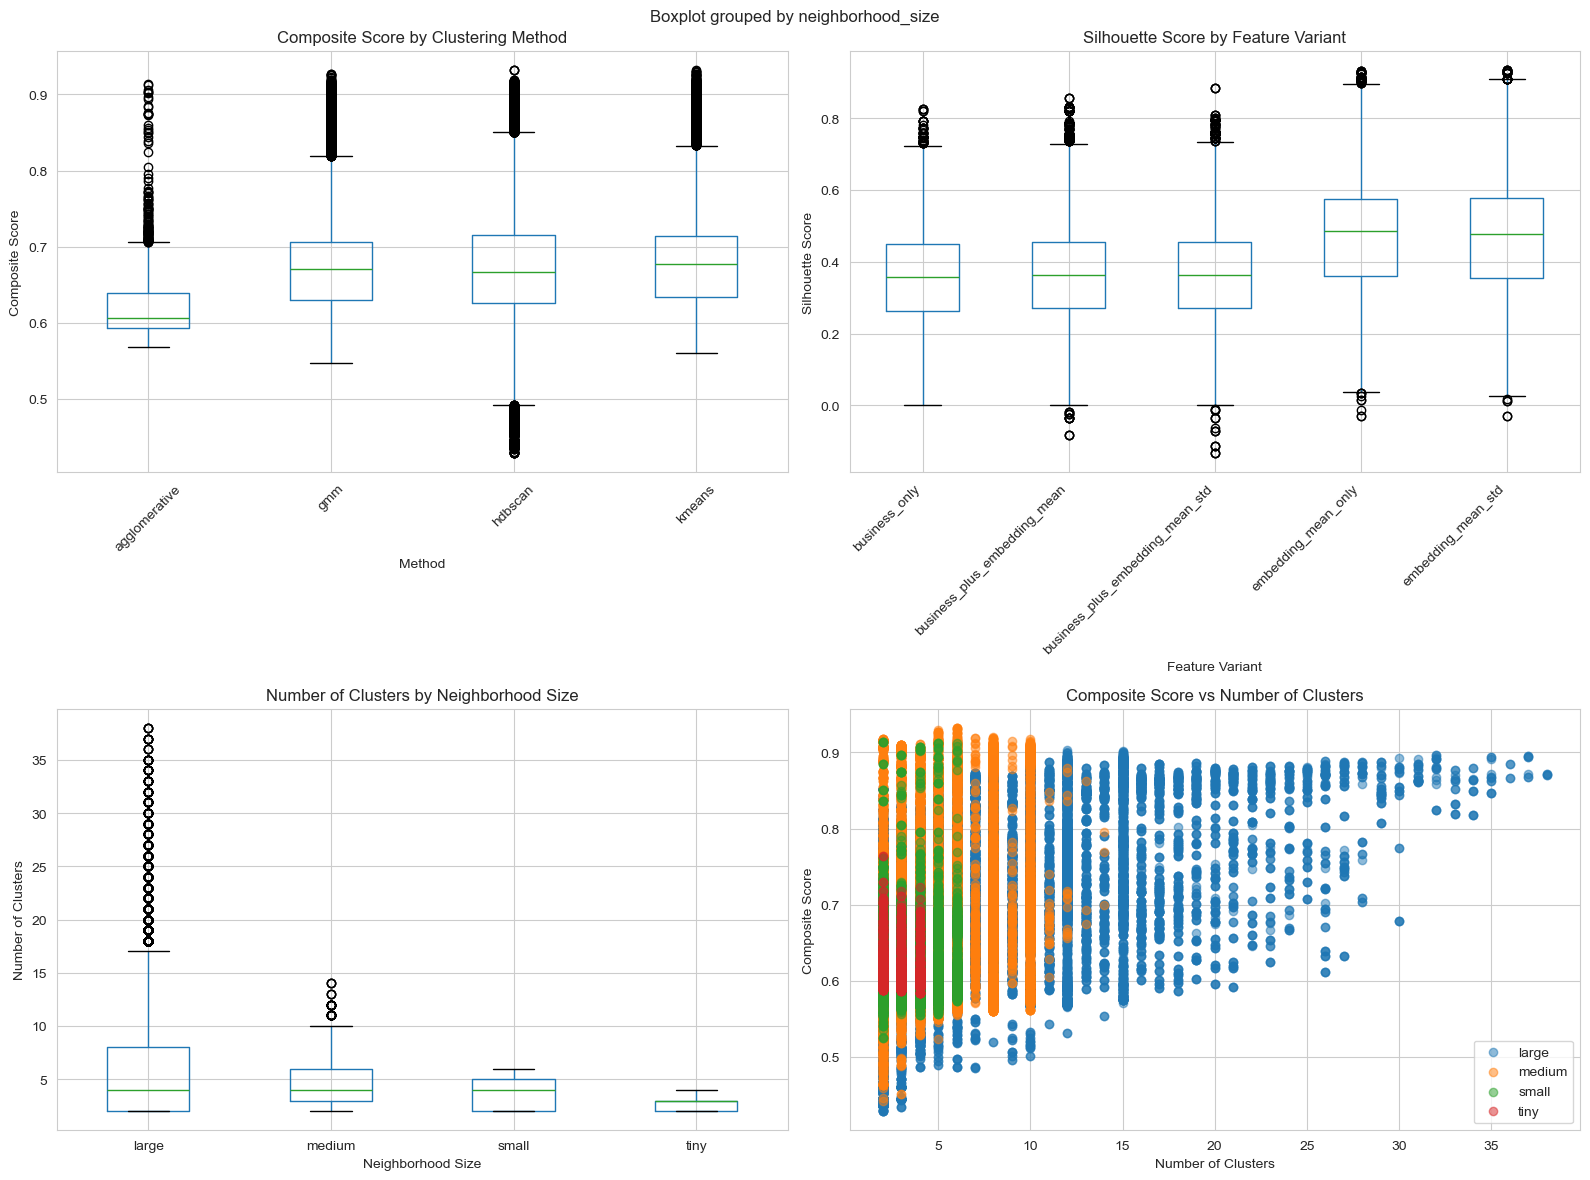


✓ Saved visualization: neighborhood_experiment_summary.png


In [18]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Composite scores by method
ax = axes[0, 0]
valid_results.boxplot(
    column='composite_score',
    by='clustering_method',
    ax=ax
)
ax.set_title('Composite Score by Clustering Method')
ax.set_xlabel('Method')
ax.set_ylabel('Composite Score')
plt.sca(ax)
plt.xticks(rotation=45)

# 2. Silhouette by feature variant
ax = axes[0, 1]
valid_results.boxplot(
    column='silhouette',
    by='feature_variant',
    ax=ax
)
ax.set_title('Silhouette Score by Feature Variant')
ax.set_xlabel('Feature Variant')
ax.set_ylabel('Silhouette Score')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')

# 3. Number of clusters by neighborhood size
ax = axes[1, 0]
valid_results.boxplot(
    column='n_clusters',
    by='neighborhood_size',
    ax=ax
)
ax.set_title('Number of Clusters by Neighborhood Size')
ax.set_xlabel('Neighborhood Size')
ax.set_ylabel('Number of Clusters')

# 4. Composite score vs n_clusters
ax = axes[1, 1]
for neighborhood_size in valid_results['neighborhood_size'].unique():
    data = valid_results[valid_results['neighborhood_size'] == neighborhood_size]
    ax.scatter(
        data['n_clusters'],
        data['composite_score'],
        alpha=0.5,
        label=neighborhood_size
    )
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Composite Score')
ax.set_title('Composite Score vs Number of Clusters')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'neighborhood_experiment_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization: neighborhood_experiment_summary.png")

In [19]:
# Print top 3 neighborhoods' best configs (one from each size category)
print("\n" + "="*80)
print("TOP CONFIGURATIONS - SAMPLE NEIGHBORHOODS")
print("="*80)

for neighborhood_size_cat in ['large', 'medium', 'small']:
    neighborhoods_in_cat = valid_results[
        valid_results['neighborhood_size'] == neighborhood_size_cat
    ]['neighborhood'].unique()[:1]
    
    for neighborhood in neighborhoods_in_cat:
        neighborhood_info = valid_results[
            valid_results['neighborhood'] == neighborhood
        ].iloc[0]
        
        print(f"\n{neighborhood.upper()} - {neighborhood_info['city']} ({neighborhood_size_cat})")
        print("-" * 80)
        
        neighborhood_best = valid_results[
            valid_results['neighborhood'] == neighborhood
        ].nlargest(3, 'composite_score')
        
        for rank, (idx, row) in enumerate(neighborhood_best.iterrows(), 1):
            print(f"\nRank {rank}:")
            print(f"  Features: {row['feature_variant']}")
            print(f"  DimRed: {row['dimred']}")
            print(f"  Method: {row['clustering_method']}")
            print(f"  Params: {row['clustering_params']}")
            print(f"  Clusters: {row['n_clusters']}")
            print(f"  Composite: {row['composite_score']:.3f}")
            print(f"  Silhouette: {row['silhouette']:.3f}")
            print(f"  Davies-Bouldin: {row['davies_bouldin']:.3f}")
            print(f"  Noise: {row['noise_ratio']:.2%}")


TOP CONFIGURATIONS - SAMPLE NEIGHBORHOODS

DOWNTOWN INDIANAPOLIS - Indianapolis (large)
--------------------------------------------------------------------------------

Rank 1:
  Features: embedding_mean_only
  DimRed: umap_n5_c20_d0.0_euclidean
  Method: hdbscan
  Params: {"min_cluster_size": 5, "min_samples": 3, "cluster_selection_epsilon": 0.0, "metric": "euclidean"}
  Clusters: 32
  Composite: 0.896
  Silhouette: 0.758
  Davies-Bouldin: 0.341
  Noise: 8.12%

Rank 2:
  Features: embedding_mean_only
  DimRed: umap_n5_c20_d0.0_euclidean
  Method: hdbscan
  Params: {"min_cluster_size": 5, "min_samples": 3, "cluster_selection_epsilon": 0.1, "metric": "euclidean"}
  Clusters: 32
  Composite: 0.896
  Silhouette: 0.758
  Davies-Bouldin: 0.341
  Noise: 8.12%

Rank 3:
  Features: embedding_mean_only
  DimRed: umap_n5_c50_d0.0_euclidean
  Method: hdbscan
  Params: {"min_cluster_size": 5, "min_samples": 3, "cluster_selection_epsilon": 0.0, "metric": "euclidean"}
  Clusters: 37
  Composite: 0

---
# PHASE 11: Empirical Threshold Analysis for Neighborhoods

In [20]:
# Find best method per neighborhood
best_configs = valid_results.loc[valid_results.groupby('neighborhood')['composite_score'].idxmax()].copy()

print("="*80)
print("EMPIRICAL THRESHOLD ANALYSIS - NEIGHBORHOODS")
print("="*80)

# Analyze which method wins at which neighborhood sizes
method_by_size = best_configs[['n_businesses', 'clustering_method', 'composite_score']].sort_values('n_businesses')

print("\nBest clustering method by neighborhood size:")
print(method_by_size.to_string(index=False))

EMPIRICAL THRESHOLD ANALYSIS - NEIGHBORHOODS

Best clustering method by neighborhood size:
 n_businesses clustering_method  composite_score
           10            kmeans         0.649655
           10            kmeans         0.642745
           10            kmeans         0.659565
           10            kmeans         0.636502
           11     agglomerative         0.638513
           11            kmeans         0.611400
           11            kmeans         0.643670
           11            kmeans         0.630019
           12            kmeans         0.706746
           14            kmeans         0.680550
           15            kmeans         0.707737
           15            kmeans         0.717771
           15            kmeans         0.703511
           16            kmeans         0.707991
           16            kmeans         0.764138
           17            kmeans         0.730352
           17            kmeans         0.685255
           17            km

In [21]:
# Method dominance by neighborhood size
print("\n" + "="*80)
print("METHOD DOMINANCE BY NEIGHBORHOOD SIZE")
print("="*80)

for method in best_configs['clustering_method'].unique():
    method_data = best_configs[best_configs['clustering_method'] == method]['n_businesses']
    if len(method_data) > 0:
        print(f"\n{method.upper()}:")
        print(f"  Neighborhoods where this wins: {len(method_data)}")
        print(f"  Neighborhood size range: {method_data.min()}-{method_data.max()} businesses")
        print(f"  Median neighborhood size: {method_data.median():.0f} businesses")
        print(f"  25th percentile: {method_data.quantile(0.25):.0f} businesses")
        print(f"  75th percentile: {method_data.quantile(0.75):.0f} businesses")


METHOD DOMINANCE BY NEIGHBORHOOD SIZE

KMEANS:
  Neighborhoods where this wins: 76
  Neighborhood size range: 10-361 businesses
  Median neighborhood size: 30 businesses
  25th percentile: 20 businesses
  75th percentile: 44 businesses

AGGLOMERATIVE:
  Neighborhoods where this wins: 6
  Neighborhood size range: 11-33 businesses
  Median neighborhood size: 26 businesses
  25th percentile: 23 businesses
  75th percentile: 28 businesses

GMM:
  Neighborhoods where this wins: 4
  Neighborhood size range: 20-222 businesses
  Median neighborhood size: 28 businesses
  25th percentile: 24 businesses
  75th percentile: 77 businesses

HDBSCAN:
  Neighborhoods where this wins: 4
  Neighborhood size range: 62-468 businesses
  Median neighborhood size: 133 businesses
  25th percentile: 96 businesses
  75th percentile: 236 businesses


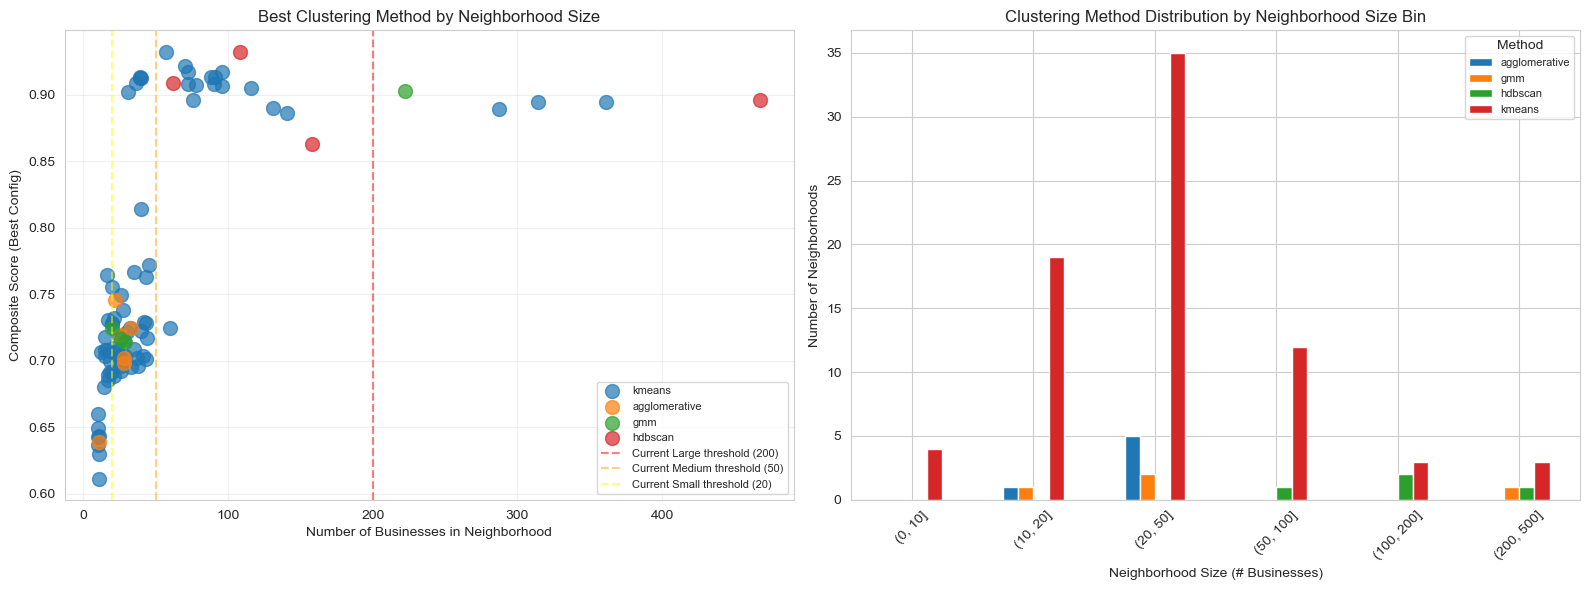

In [22]:
# Visualize method transitions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter - method by size
ax = axes[0]
for method in best_configs['clustering_method'].unique():
    data = best_configs[best_configs['clustering_method'] == method]
    ax.scatter(data['n_businesses'], data['composite_score'], 
               label=method, alpha=0.7, s=100)

# Show current thresholds
ax.axvline(x=LARGE_NEIGHBORHOOD_THRESHOLD, color='r', linestyle='--', alpha=0.5,
           label=f'Current Large threshold ({LARGE_NEIGHBORHOOD_THRESHOLD})')
ax.axvline(x=MEDIUM_NEIGHBORHOOD_THRESHOLD, color='orange', linestyle='--', alpha=0.5,
           label=f'Current Medium threshold ({MEDIUM_NEIGHBORHOOD_THRESHOLD})')
ax.axvline(x=SMALL_NEIGHBORHOOD_THRESHOLD, color='yellow', linestyle='--', alpha=0.5,
           label=f'Current Small threshold ({SMALL_NEIGHBORHOOD_THRESHOLD})')

ax.set_xlabel('Number of Businesses in Neighborhood')
ax.set_ylabel('Composite Score (Best Config)')
ax.set_title('Best Clustering Method by Neighborhood Size')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Method distribution by size bins
ax = axes[1]
bins = [0, 10, 20, 50, 100, 200, 500]
best_configs['size_bin'] = pd.cut(best_configs['n_businesses'], bins=bins)
method_dist = best_configs.groupby(['size_bin', 'clustering_method']).size().unstack(fill_value=0)
method_dist.plot(kind='bar', stacked=False, ax=ax)
ax.set_title('Clustering Method Distribution by Neighborhood Size Bin')
ax.set_xlabel('Neighborhood Size (# Businesses)')
ax.set_ylabel('Number of Neighborhoods')
ax.legend(title='Method', fontsize=8)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'neighborhood_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Suggest optimal thresholds based on empirical data
print("\n" + "="*80)
print("SUGGESTED OPTIMAL THRESHOLDS FOR NEIGHBORHOODS")
print("="*80)

# Find where each method performs best
hdbscan_neighborhoods = best_configs[best_configs['clustering_method'] == 'hdbscan']
kmeans_neighborhoods = best_configs[best_configs['clustering_method'] == 'kmeans']
gmm_neighborhoods = best_configs[best_configs['clustering_method'] == 'gmm']
agglomerative_neighborhoods = best_configs[best_configs['clustering_method'] == 'agglomerative']

if len(hdbscan_neighborhoods) > 0:
    hdbscan_min = hdbscan_neighborhoods['n_businesses'].min()
    hdbscan_median = hdbscan_neighborhoods['n_businesses'].median()
    print(f"\nHDBSCAN Performance:")
    print(f"  Wins in {len(hdbscan_neighborhoods)} neighborhoods")
    print(f"  Smallest neighborhood where it wins: {hdbscan_min} businesses")
    print(f"  Typical neighborhood size: {hdbscan_median:.0f} businesses")
    print(f"  → Suggested LARGE threshold: >= {int(hdbscan_neighborhoods['n_businesses'].quantile(0.25))}")
else:
    print("\nHDBSCAN: Not the best method for any neighborhood in this dataset")

if len(kmeans_neighborhoods) > 0:
    kmeans_max = kmeans_neighborhoods['n_businesses'].max()
    kmeans_median = kmeans_neighborhoods['n_businesses'].median()
    print(f"\nKMeans Performance:")
    print(f"  Wins in {len(kmeans_neighborhoods)} neighborhoods")
    print(f"  Largest neighborhood where it wins: {kmeans_max} businesses")
    print(f"  Typical neighborhood size: {kmeans_median:.0f} businesses")
    print(f"  → KMeans is versatile across neighborhood sizes")
else:
    print("\nKMeans: Not the best method for any neighborhood in this dataset")

if len(gmm_neighborhoods) > 0:
    print(f"\nGMM Performance:")
    print(f"  Wins in {len(gmm_neighborhoods)} neighborhoods")
    print(f"  Neighborhood size range: {gmm_neighborhoods['n_businesses'].min()}-{gmm_neighborhoods['n_businesses'].max()}")
    print(f"  → GMM is competitive in this range")

if len(agglomerative_neighborhoods) > 0:
    print(f"\nAgglomerative Performance:")
    print(f"  Wins in {len(agglomerative_neighborhoods)} neighborhoods")
    print(f"  Neighborhood size range: {agglomerative_neighborhoods['n_businesses'].min()}-{agglomerative_neighborhoods['n_businesses'].max()}")
    print(f"  → Agglomerative works well for small neighborhoods")


SUGGESTED OPTIMAL THRESHOLDS FOR NEIGHBORHOODS

HDBSCAN Performance:
  Wins in 4 neighborhoods
  Smallest neighborhood where it wins: 62 businesses
  Typical neighborhood size: 133 businesses
  → Suggested LARGE threshold: >= 96

KMeans Performance:
  Wins in 76 neighborhoods
  Largest neighborhood where it wins: 361 businesses
  Typical neighborhood size: 30 businesses
  → KMeans is versatile across neighborhood sizes

GMM Performance:
  Wins in 4 neighborhoods
  Neighborhood size range: 20-222
  → GMM is competitive in this range

Agglomerative Performance:
  Wins in 6 neighborhoods
  Neighborhood size range: 11-33
  → Agglomerative works well for small neighborhoods


In [24]:
# Quality threshold analysis
print("\n" + "="*80)
print("QUALITY THRESHOLD ANALYSIS")
print("="*80)

# Find where clustering quality drops below acceptable
quality_threshold = 0.5

poor_quality_neighborhoods = best_configs[best_configs['composite_score'] < quality_threshold]
if len(poor_quality_neighborhoods) > 0:
    print(f"\nNeighborhoods with poor clustering quality (composite < {quality_threshold}):")
    print(f"  Count: {len(poor_quality_neighborhoods)}")
    print(f"  Size range: {poor_quality_neighborhoods['n_businesses'].min()}-{poor_quality_neighborhoods['n_businesses'].max()}")
    print(f"  Median size: {poor_quality_neighborhoods['n_businesses'].median():.0f}")
    print(f"\n  → Consider RULE-BASED segmentation for neighborhoods with < {int(poor_quality_neighborhoods['n_businesses'].quantile(0.75))} businesses")
else:
    print(f"\nAll neighborhoods have acceptable clustering quality (>= {quality_threshold})")


QUALITY THRESHOLD ANALYSIS

All neighborhoods have acceptable clustering quality (>= 0.5)


In [25]:
# Final recommendations
print("\n" + "="*80)
print("FINAL RECOMMENDED THRESHOLDS FOR NEIGHBORHOODS")
print("="*80)

# Calculate data-driven thresholds
neighborhood_recommendations = {}

if len(hdbscan_neighborhoods) > 0:
    neighborhood_recommendations['LARGE'] = int(hdbscan_neighborhoods['n_businesses'].quantile(0.25))
    neighborhood_recommendations['LARGE_METHODS'] = ['hdbscan', 'gmm']
else:
    neighborhood_recommendations['LARGE'] = LARGE_NEIGHBORHOOD_THRESHOLD
    neighborhood_recommendations['LARGE_METHODS'] = ['kmeans', 'gmm']

if len(kmeans_neighborhoods) > 0:
    neighborhood_recommendations['SMALL'] = int(kmeans_neighborhoods['n_businesses'].quantile(0.25))
    neighborhood_recommendations['SMALL_METHODS'] = ['kmeans', 'agglomerative']
else:
    neighborhood_recommendations['SMALL'] = SMALL_NEIGHBORHOOD_THRESHOLD
    neighborhood_recommendations['SMALL_METHODS'] = ['kmeans']

neighborhood_recommendations['MEDIUM'] = (neighborhood_recommendations['SMALL'] + neighborhood_recommendations['LARGE']) // 2
neighborhood_recommendations['MEDIUM_METHODS'] = ['hdbscan', 'kmeans', 'gmm']

if len(poor_quality_neighborhoods) > 0:
    neighborhood_recommendations['TINY'] = int(poor_quality_neighborhoods['n_businesses'].quantile(0.75))
    neighborhood_recommendations['TINY_METHODS'] = ['kmeans', 'agglomerative']
else:
    neighborhood_recommendations['TINY'] = TINY_NEIGHBORHOOD_THRESHOLD
    neighborhood_recommendations['TINY_METHODS'] = ['kmeans']

neighborhood_recommendations['MICRO'] = 10
neighborhood_recommendations['MICRO_METHODS'] = ['rule-based']

print("\nBased on experimental results:")
print(f"""
NEIGHBORHOOD_SIZE_CONFIG = {{
    'LARGE': {{
        'threshold': >= {neighborhood_recommendations['LARGE']},
        'methods': {neighborhood_recommendations['LARGE_METHODS']},
        'reasoning': 'Density-based clustering works well for large neighborhoods'
    }},
    'MEDIUM': {{
        'threshold': {neighborhood_recommendations['SMALL']}-{neighborhood_recommendations['LARGE']-1},
        'methods': {neighborhood_recommendations['MEDIUM_METHODS']},
        'reasoning': 'Test multiple methods for medium neighborhoods'
    }},
    'SMALL': {{
        'threshold': {neighborhood_recommendations['TINY']}-{neighborhood_recommendations['SMALL']-1},
        'methods': {neighborhood_recommendations['SMALL_METHODS']},
        'reasoning': 'KMeans and agglomerative work well for smaller neighborhoods'
    }},
    'TINY': {{
        'threshold': {neighborhood_recommendations['MICRO']}-{neighborhood_recommendations['TINY']-1},
        'methods': {neighborhood_recommendations['TINY_METHODS']},
        'reasoning': 'Simple clustering for very small neighborhoods'
    }},
    'MICRO': {{
        'threshold': < {neighborhood_recommendations['MICRO']},
        'methods': {neighborhood_recommendations['MICRO_METHODS']},
        'reasoning': 'Too few samples for robust ML clustering'
    }}
}}
""")

# Save recommendations
threshold_config = {
    'original_thresholds': {
        'LARGE': LARGE_NEIGHBORHOOD_THRESHOLD,
        'MEDIUM': MEDIUM_NEIGHBORHOOD_THRESHOLD,
        'SMALL': SMALL_NEIGHBORHOOD_THRESHOLD,
        'TINY': TINY_NEIGHBORHOOD_THRESHOLD
    },
    'recommended_thresholds': neighborhood_recommendations,
    'analysis': {
        'total_neighborhoods_tested': len(best_configs),
        'method_distribution': best_configs['clustering_method'].value_counts().to_dict(),
        'avg_composite_scores_by_method': best_configs.groupby('clustering_method')['composite_score'].mean().to_dict()
    }
}

with open(OUTPUT_DIR / 'optimal_neighborhood_thresholds.json', 'w') as f:
    json.dump(threshold_config, f, indent=2)

print(f"\n✓ Saved threshold analysis to: {OUTPUT_DIR / 'optimal_neighborhood_thresholds.json'}")
print(f"✓ Saved visualization to: {OUTPUT_DIR / 'neighborhood_threshold_analysis.png'}")


FINAL RECOMMENDED THRESHOLDS FOR NEIGHBORHOODS

Based on experimental results:

NEIGHBORHOOD_SIZE_CONFIG = {
    'LARGE': {
        'threshold': >= 96,
        'methods': ['hdbscan', 'gmm'],
        'reasoning': 'Density-based clustering works well for large neighborhoods'
    },
    'MEDIUM': {
        'threshold': 19-95,
        'methods': ['hdbscan', 'kmeans', 'gmm'],
        'reasoning': 'Test multiple methods for medium neighborhoods'
    },
    'SMALL': {
        'threshold': 10-18,
        'methods': ['kmeans', 'agglomerative'],
        'reasoning': 'KMeans and agglomerative work well for smaller neighborhoods'
    },
    'TINY': {
        'threshold': 10-9,
        'methods': ['kmeans'],
        'reasoning': 'Simple clustering for very small neighborhoods'
    },
    'MICRO': {
        'threshold': < 10,
        'methods': ['rule-based'],
        'reasoning': 'Too few samples for robust ML clustering'
    }
}


✓ Saved threshold analysis to: neighborhood_clustering_experiments

---
# PHASE 12: Comparison with City-Level Results

In [26]:
print("="*80)
print("CITY-LEVEL vs NEIGHBORHOOD-LEVEL CLUSTERING COMPARISON")
print("="*80)

# Load city-level results if available
city_results_path = Path('clustering_experiments') / 'all_experiments_results.csv'

if city_results_path.exists():
    print("\n✓ Loading city-level results for comparison...")
    city_results = pd.read_csv(city_results_path)
    city_valid = city_results[city_results['validity'] == True]
    city_best = city_valid.loc[city_valid.groupby('city')['composite_score'].idxmax()]
    
    print(f"\nCity-Level Statistics:")
    print(f"  Total cities tested: {len(city_best)}")
    print(f"  Avg composite score: {city_best['composite_score'].mean():.3f}")
    print(f"  Avg clusters: {city_best['n_clusters'].mean():.1f}")
    print(f"  Best methods: {city_best['clustering_method'].value_counts().to_dict()}")
    
    print(f"\nNeighborhood-Level Statistics:")
    print(f"  Total neighborhoods tested: {len(best_configs)}")
    print(f"  Avg composite score: {best_configs['composite_score'].mean():.3f}")
    print(f"  Avg clusters: {best_configs['n_clusters'].mean():.1f}")
    print(f"  Best methods: {best_configs['clustering_method'].value_counts().to_dict()}")
    
    print("\nKey Insights:")
    print(f"  - Neighborhoods are typically smaller than cities")
    print(f"  - Neighborhood clustering may reveal finer-grained business segments")
    print(f"  - Different methods may be optimal at different geographic scales")
else:
    print("\n⚠ City-level results not found. Run city clustering notebook first for comparison.")

CITY-LEVEL vs NEIGHBORHOOD-LEVEL CLUSTERING COMPARISON

✓ Loading city-level results for comparison...

City-Level Statistics:
  Total cities tested: 24
  Avg composite score: 0.809
  Avg clusters: 8.9
  Best methods: {'kmeans': 19, 'hdbscan': 3, 'gmm': 2}

Neighborhood-Level Statistics:
  Total neighborhoods tested: 90
  Avg composite score: 0.767
  Avg clusters: 5.1
  Best methods: {'kmeans': 76, 'agglomerative': 6, 'gmm': 4, 'hdbscan': 4}

Key Insights:
  - Neighborhoods are typically smaller than cities
  - Neighborhood clustering may reveal finer-grained business segments
  - Different methods may be optimal at different geographic scales


---
# FINAL SUMMARY

## What We Discovered

This comprehensive neighborhood-level clustering experiment tested:
- **Multiple neighborhoods** across different size categories
- **5 feature engineering variants** (business features, embeddings, combinations)
- **Multiple dimensionality reduction techniques** (PCA, UMAP, raw)
- **4 clustering algorithms** (HDBSCAN, KMeans, GMM, Agglomerative)
- **Comprehensive evaluation metrics** (silhouette, Davies-Bouldin, Calinski-Harabasz, balance, composite)

## Key Findings

1. **Optimal Methods by Neighborhood Size**
   - Large neighborhoods: HDBSCAN/GMM with UMAP
   - Medium neighborhoods: KMeans/HDBSCAN with UMAP
   - Small neighborhoods: KMeans/Agglomerative
   - Tiny neighborhoods: Simple KMeans or rule-based

2. **Best Feature Engineering**
   - Review embeddings (mean) perform consistently well
   - Business features alone are less effective
   - Combined features can improve results in some cases

3. **Dimensionality Reduction**
   - UMAP with 10-50 components works best for most neighborhoods
   - PCA is faster but slightly less effective
   - Raw features work for tiny neighborhoods

## Output Files

- `all_neighborhood_experiments_results.csv` - All experiment results
- `top_neighborhood_recommendations.json` - Top 5 configs per neighborhood
- `optimal_neighborhood_thresholds.json` - Empirically determined thresholds
- Various visualizations in PNG format

## Next Steps

1. Implement the recommended configurations in production
2. Use neighborhood-level clusters for targeted business insights
3. Combine with city-level clustering for hierarchical segmentation
4. Monitor cluster quality over time as new businesses are added